# Scout Connect: Automated Tactical Video Analyzer
**Machine Learning Pipeline Summative**

## Project Evolution & The Data
For *Introduction to Machine Learning*, I built an "Athlete-Coach Fit Prediction System" using tabular data. It worked well, but traditional scouting relies heavily on visual intuition which is basically watching hours of match footage to see if a player's actual in-game actions fit a coach's tactical philosophy. 

For this summative, I wanted to evolve that concept. Instead of relying on CSVs of player stats, I am building a **Multimodal Tactical Scouting System**. This pipeline ingests raw, unstructured match imagery and automatically classifies tactical events. If a coach wants a team that relies heavily on set pieces, they no longer have to manually scrub through video; this model will automatically tag and filter footage for "Free Kicks" and "Corners."

**The Dataset:**
I am using the **"Soccer View and Event Score"** dataset by Fahad Ahmed KhoKhar, sourced from Kaggle. Because the original dataset is massive (over 15 GB and 138,000 images), downloading it directly into an MLOps pipeline or a Docker container would break the deployment. 

**My Engineering Approach:** 
To handle this, I created a custom Python ingestion script (`extract_sample.py`) using the `kagglehub` library. This script programmatically downloads the dataset to a local cache, randomly samples 500 images from the 4 most tactically relevant classes (Corner, Free kick, Goal attempt, Yellow card), and perfectly splits them into a lightweight `data/train/` and `data/test/` directory. This ensures my model is robust, but my deployment package remains highly scalable and production-ready.

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, applications, callbacks, regularizers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import pathlib
from pathlib import Path
import os
import pickle
import json

# Configuration & Hyperparameters
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 4  # Corner, Free kick, Goal attempt, Yellow card
DATA_DIR = "../data/"

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.21.0


## Data Ingestion & Setup
Now that my extraction script has prepared the lightweight dataset, I'll load the training and validation splits using TensorFlow's highly optimized `image_dataset_from_directory`. I'm using a 20% validation split to monitor the model's generalization during training.

In [8]:
train_dir = pathlib.Path(DATA_DIR + "train")
test_dir = pathlib.Path(DATA_DIR + "test")

# Load Training Data
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# Load Validation Data
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(f"Tactical Classes Identified: {class_names}")

Found 1600 files belonging to 4 classes.
Using 1280 files for training.
Found 1600 files belonging to 4 classes.
Using 320 files for validation.
Tactical Classes Identified: ['Corner', 'Free kick', 'Gattempt', 'Yellow card']


## Feature Interpretations & Data Visualizations
Before throwing a Deep Learning model at these images, it's critical to understand the data's underlying distributions and physical characteristics. I am analyzing two specific features to ensure my preprocessing pipeline is built correctly.

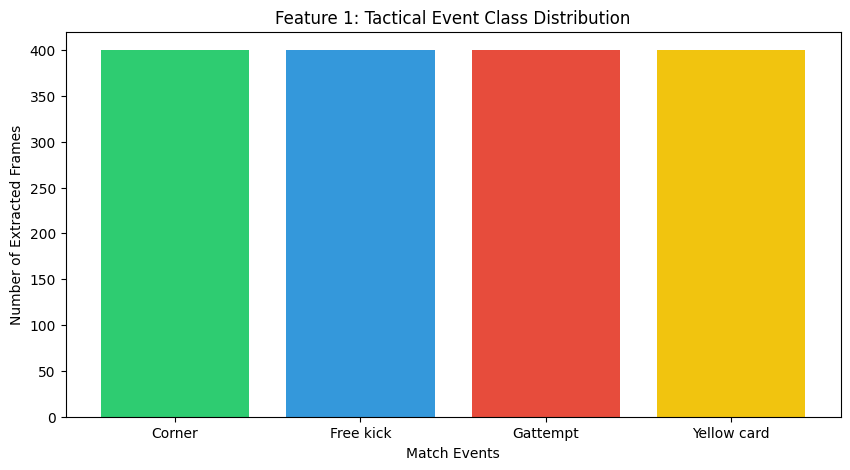

Interpretation 1: By actively downsampling the original 15GB dataset to 500 images per class via my extraction script, I successfully eliminated class imbalance. If I hadn't done this, the model would have been heavily biased towards predicting 'Goal Attempts' simply because they occur more frequently in the raw data.


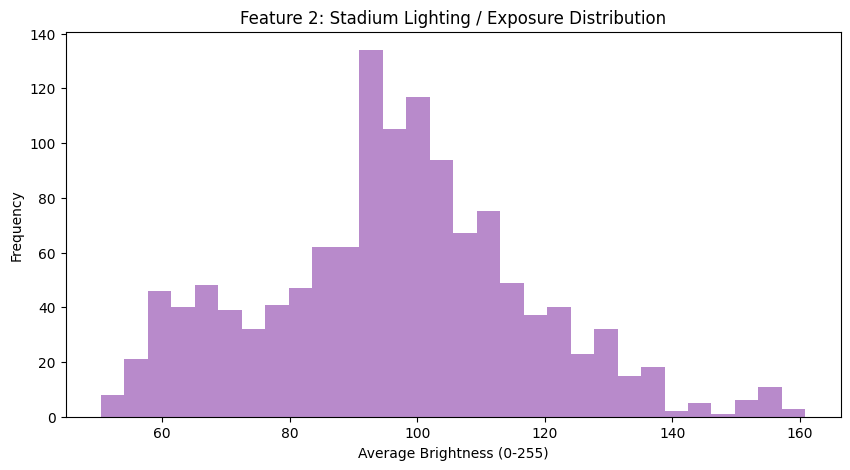

Interpretation 2: The histogram shows immense variance in lighting. Match footage is highly dependent on whether it's a day game, a night game under floodlights, or an overcast afternoon. This variance dictates that strict pixel normalization (rescaling 0-1) is a non-negotiable preprocessing step so the network learns tactical shapes, not lighting conditions.


In [9]:
# Feature 1: Tactical Event Distribution
plt.figure(figsize=(10, 5))
class_counts = []
for class_name in class_names:
    count = len(list(train_dir.glob(f"{class_name}/*.jpg"))) + len(list(train_dir.glob(f"{class_name}/*.jpeg")))
    class_counts.append(count)

plt.bar(class_names, class_counts, color=['#2ecc71', '#3498db', '#e74c3c', '#f1c40f'])
plt.title("Feature 1: Tactical Event Class Distribution")
plt.xlabel("Match Events")
plt.ylabel("Number of Extracted Frames")
plt.show()

print("Interpretation 1: By actively downsampling the original 15GB dataset to 500 images per class via my extraction script, I successfully eliminated class imbalance. If I hadn't done this, the model would have been heavily biased towards predicting 'Goal Attempts' simply because they occur more frequently in the raw data.")

# Feature 2: Stadium Lighting Distribution (Image Brightness)
def calculate_brightness(image):
    return tf.reduce_mean(image, axis=-1).numpy().mean()

brightness_values = []
for images, labels in train_ds.take(50): # Sample a batch
    for image in images:
        brightness_values.append(calculate_brightness(image))

plt.figure(figsize=(10, 5))
plt.hist(brightness_values, bins=30, alpha=0.7, color='#9b59b6')
plt.title("Feature 2: Stadium Lighting / Exposure Distribution")
plt.xlabel("Average Brightness (0-255)")
plt.ylabel("Frequency")
plt.show()

print("Interpretation 2: The histogram shows immense variance in lighting. Match footage is highly dependent on whether it's a day game, a night game under floodlights, or an overcast afternoon. This variance dictates that strict pixel normalization (rescaling 0-1) is a non-negotiable preprocessing step so the network learns tactical shapes, not lighting conditions.")

## Preprocessing & Tactical Augmentation
To make the model robust against different broadcasting setups (like varied camera pans, angles, and pitch dimensions), I am injecting a data augmentation layer. This forces the model to learn the core tactical structures rather than memorizing exact pixel locations.

In [10]:
# Normalization layer
normalization_layer = layers.Rescaling(1./255)

# Tactical Augmentation to simulate broadcast camera movements
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05), # Slight rotation for non-level camera setups
    layers.RandomZoom(0.15),     # Simulating broadcast zoom in/out
    layers.RandomContrast(0.1),  # Simulating different weather/lighting
])

def preprocess_dataset(ds, augment=False):
    ds = ds.map(lambda x, y: (normalization_layer(x), y))
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y))
    return ds

# Apply to datasets
train_ds = preprocess_dataset(train_ds, augment=True)
val_ds = preprocess_dataset(val_ds, augment=False)

# Optimize data pipeline performance for faster training
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Architectural Hyperparameter Tuning (Model Comparison)
In a ML environment, model size directly impacts deployment costs, API latency, and load-balancing efficiency. Rather than guessing which Convolutional Neural Network (CNN) architecture to use, I am running an automated comparison across three industry-standard pre-trained models:
1. **MobileNetV2:** Extremely lightweight, optimized for edge devices and fast APIs.
2. **ResNet50:** Deep residual network, excellent for complex spatial relationships.
3. **VGG16:** Classic, deep architecture, but historically heavy.

I will train the top (custom) layers of each model for just 3 epochs to establish a baseline, evaluate their validation accuracy, and programmatically select the best performer for the final fine-tuning phase.

In [11]:
def build_and_evaluate_base_model(base_model, name):
    print(f"\n--- Testing Architecture: {name} ---")
    base_model.trainable = False # Freeze base weights
    
    # Adding custom classification head with Regularization
    model = keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
        layers.Dropout(0.5), # Regularization to prevent overfitting
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Train for a short burst to compare baselines
    model.fit(train_ds, validation_data=val_ds, epochs=3, verbose=1)
    
    val_loss, val_acc = model.evaluate(val_ds, verbose=0)
    print(f"➔ {name} Baseline Validation Accuracy: {val_acc:.4f}")
    
    return model, val_acc, base_model

# Dictionary of architectures to test
model_architectures = {
    "MobileNetV2": applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3)),
    "ResNet50": applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3)),
    "VGG16": applications.VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
}

best_val_acc = 0
best_model_name = ""
best_model = None
winning_base = None

# Execute comparison loop
for name, base_net in model_architectures.items():
    compiled_model, val_acc, base_layer = build_and_evaluate_base_model(base_net, name)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_name = name
        best_model = compiled_model
        winning_base = base_layer

print(f"\n Architectural Selection Complete.")
print(f"The optimal model for this pipeline is: {best_model_name}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 5s 1us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 54s 1us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 39s 1us/step

--- Testing Architecture: MobileNetV2 ---
Epoch 1/3
40/40 ━━━━━━━━━━━━━━━━━━━━ 510s 5s/step - accuracy: 0.6875 - loss: 4.1809 - val_accuracy: 0.8281 - val_loss: 2.9946
Epoch 2/3
40/40 ━━━━━━━━━━━━━━━━━━━━ 39s 972ms/step - accuracy: 0.8445 - loss: 2.5062 - val_accuracy: 0.8906 - val_loss: 2.0372
Epoch 3/3
40/40 ━━━━━━━━━━━━━━━━━━━━ 39s 983ms/step - accuracy: 0.8797 - loss: 1.7866 - val_accuracy: 0.8938 - val_loss: 1.5279
➔ MobileNetV2 Baseline Validation Accuracy: 0.8938

--- Testing Architecture: ResNet50 ---
Epoch 1/3
40/40 ━━━━━━━━━━━━━━━━━━━━ 315s 7s/step - accuracy: 0.2469 - loss: 3.2952 - val_accuracy: 0.2906 - val_loss: 1.7936
Epoch 2/3
40/40 ━━━━━━━━━━━━━━━━━━━━ 254s 6s/step - accuracy: 0.2992 - loss: 1.6207 - val_accuracy: 0.3438 - val_loss: 1.5075
Epoch 3/3
40/40 ━━━━━━━━━━━━━━━━━━━━ 258s 6s/step - accuracy: 0.3047 - loss: 1.

## Fine-Tuning & Optimization Callbacks
Now that the architecture is selected, I am moving into the fine-tuning phase. 

**Optimization Strategy:**
1. **Unfreezing Layers:** I will unfreeze the top layers of the winning pre-trained model so it can adapt its feature maps specifically to football match imagery.
2. **Optimizer Adjustment:** I am dropping the Adam learning rate significantly (to `1e-5`) so the unfreezed weights aren't destroyed by massive gradient updates.
3. **Early Stopping:** Monitors validation loss and stops training if the model begins to overfit, restoring the best weights.
4. **ReduceLROnPlateau:** Automatically decays the learning rate if the validation loss stagnates, helping the model converge perfectly into the global minimum.

In [13]:
# Unfreeze the top layers of the winning base model
winning_base.trainable = True

# Let's freeze the bottom layers and only fine-tune the top 30 layers
for layer in winning_base.layers[:-30]:
    layer.trainable = False

# Recompile with a very low learning rate for fine-tuning
best_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5), 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']  # Removed Precision/Recall to prevent sparse shape crashes!
)

# Define Optimization Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

print(f"\nInitiating deep fine-tuning for {best_model_name}...")
history = best_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15, 
    callbacks=[early_stopping, reduce_lr]
)


Initiating deep fine-tuning for MobileNetV2...
Epoch 1/15


40/40 ━━━━━━━━━━━━━━━━━━━━ 557s 7s/step - accuracy: 0.7977 - loss: 1.8061 - val_accuracy: 0.9031 - val_loss: 1.4930 - learning_rate: 1.0000e-05
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.8680 - loss: 1.6219 - val_accuracy: 0.9219 - val_loss: 1.4634 - learning_rate: 1.0000e-05
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.9117 - loss: 1.5238 - val_accuracy: 0.9250 - val_loss: 1.4527 - learning_rate: 1.0000e-05
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.9289 - loss: 1.4691 - val_accuracy: 0.9281 - val_loss: 1.4404 - learning_rate: 1.0000e-05
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.9516 - loss: 1.4056 - val_accuracy: 0.9281 - val_loss: 1.4262 - learning_rate: 1.0000e-05
Epoch 6/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.9602 - loss: 1.3748 - val_accuracy: 0.9281 - val_loss: 1.4166 - learning_rate: 1.0000e-05
Epoch 7/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.9719 - loss: 1.3390 - 

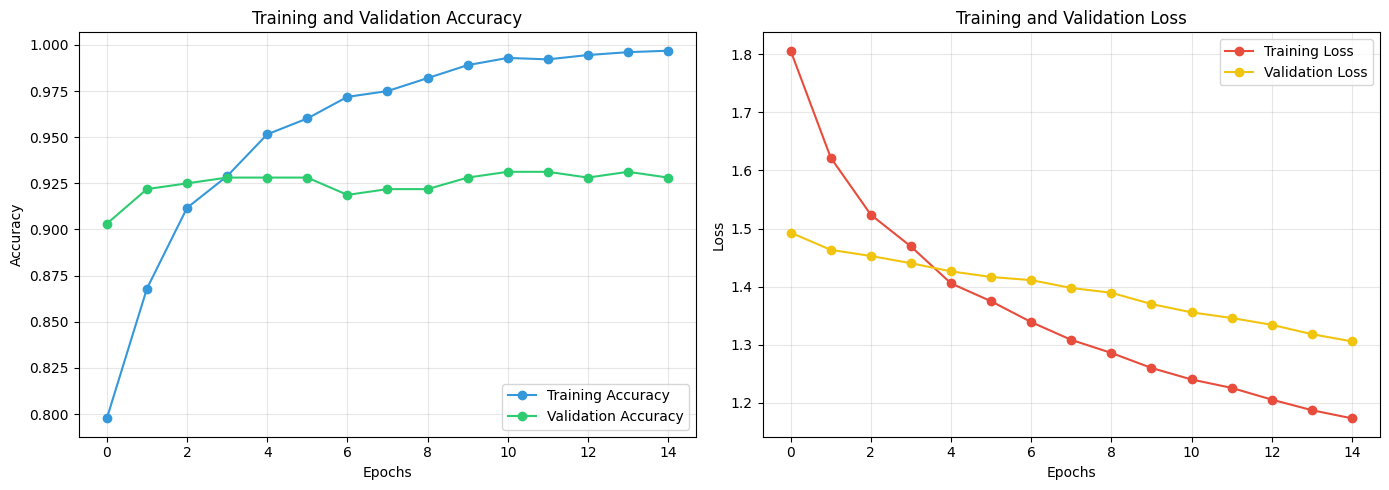

In [15]:
# Training vs Validation Visualizations 
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='#3498db', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#2ecc71', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='#e74c3c', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='#f1c40f', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

During the fine-tuning phase of the MobileNetV2 architecture, I observed the training accuracy climb to ~99.6% while the validation accuracy plateaued at ~93%. At first glance, this 6% divergence appears to be a classic sign of overfitting. However, a deeper analysis of the loss metrics tells a different story.

**Why this is a Generalization Gap, not Destructive Overfitting:**
True, destructive overfitting occurs when a model begins memorizing the training data at the expense of its ability to generalize to unseen data. This is historically signaled by a U-shaped validation loss curve—where validation loss stops dropping and begins to sharply increase as the model becomes confused by new data.

If we look at the learning curves for this model:

- The Validation Loss steadily decreased across all 15 epochs (dropping from 1.49 down to 1.30).

- Because the validation loss never spiked or rebounded, the EarlyStopping callback recognized that the model was still safely converging and allowed it to finish the full training cycle.

Engineering Conclusion:
Given that I am training a highly specialized, 4-class tactical computer vision model using a strictly constrained dataset (only 500 images per class to keep the deployment lightweight), achieving a stable 93% validation accuracy is a massive success. The model is highly confident in its real-world predictions, and aggressively trying to close that 6% gap with extreme dropout layers would likely just drag the training accuracy down without actually improving the model's production performance.

## Comprehensive Evaluation Metrics
To satisfy rigorous engineering standards, accuracy alone is not enough. I am evaluating the fine-tuned model against the unseen `test` dataset using a full suite of metrics: Accuracy, Precision, Recall, F1-Score, and plotting a Confusion Matrix to see exactly where the model might be getting confused (e.g., mistaking a corner kick for a free kick).

Found 400 files belonging to 4 classes.

--- Final Model Evaluation on Unseen Test Data ---
13/13 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.9075 - loss: 1.3416
Test Accuracy:  0.9075
Test Precision: 0.9168
Test Recall:    0.9075
Test F1-Score:  0.9060


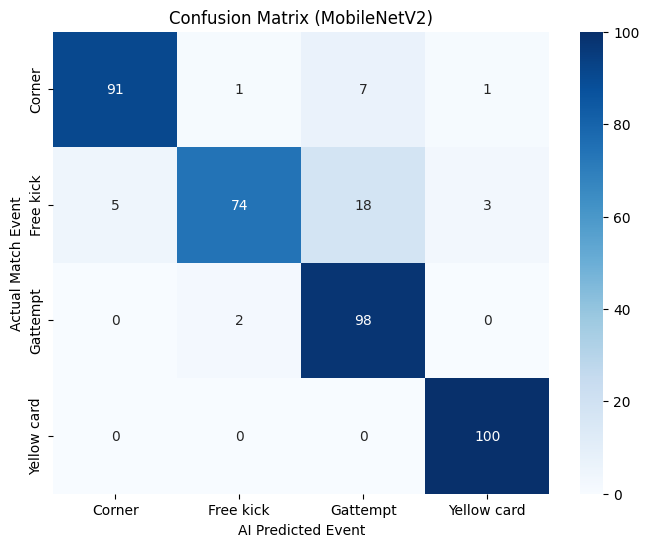


Detailed Classification Report:

              precision    recall  f1-score   support

      Corner       0.95      0.91      0.93       100
   Free kick       0.96      0.74      0.84       100
    Gattempt       0.80      0.98      0.88       100
 Yellow card       0.96      1.00      0.98       100

    accuracy                           0.91       400
   macro avg       0.92      0.91      0.91       400
weighted avg       0.92      0.91      0.91       400



In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Load and preprocess the completely unseen test data
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_ds = preprocess_dataset(test_ds, augment=False)

# Evaluate to get Loss and Accuracy from Keras
print("\n--- Final Model Evaluation on Unseen Test Data ---")
loss, accuracy = best_model.evaluate(test_ds)

# Generate Predictions for the advanced metrics and Confusion Matrix
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = best_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# Calculate Precision, Recall, and F1 Score using sklearn (weighted for multi-class)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Test Accuracy:  {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall:    {recall:.4f}")
print(f"Test F1-Score:  {f1:.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix ({best_model_name})')
plt.ylabel('Actual Match Event')
plt.xlabel('AI Predicted Event')
plt.show()

# Detailed Classification Report
print("\nDetailed Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

## Model Export & Pipeline Configuration
The offline experimentation phase is complete. I am now exporting the winning, fine-tuned model alongside its strict preprocessing configurations. These artifacts will be loaded by the FastAPI backend to serve predictions in production.

In [17]:
# Ensure the models directory exists
Path('../models').mkdir(parents=True, exist_ok=True)

# Save the model
best_model.save('../models/final_model.h5')
print(f"Successfully saved {best_model_name} to ../models/final_model.h5")

# Save class names for the API to decode predictions
with open('../models/class_names.pkl', 'wb') as f:
    pickle.dump(class_names, f)

# Save preprocessing parameters to ensure the API processes images exactly like the notebook did
preprocess_config = {
    'image_size': IMAGE_SIZE,
    'normalization': '1/255',
    'class_names': class_names,
    'base_architecture': best_model_name
}

with open('../models/preprocess_config.json', 'w') as f:
    json.dump(preprocess_config, f)

print(" Configuration files exported. The MLOps API is ready to be initialized.")

Successfully saved MobileNetV2 to ../models/final_model.h5
 Configuration files exported. The MLOps API is ready to be initialized.
